In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("cleaned_online_retail.xlsx")

# Exploratory Data Analysis (EDA)

# Dataset Understanding

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
df.shape

(210716, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210716 entries, 0 to 210715
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    210716 non-null  int64         
 1   StockCode    210716 non-null  object        
 2   Description  210716 non-null  object        
 3   Quantity     210716 non-null  int64         
 4   InvoiceDate  210716 non-null  datetime64[ns]
 5   UnitPrice    210716 non-null  float64       
 6   CustomerID   210716 non-null  int64         
 7   Country      210716 non-null  object        
 8   Revenue      210716 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 14.5+ MB


In [7]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,210716.000000,210716.000000,210716,210716.000000,210716.000000,210716.000000
mean,549983.103542,13.580298,2011-04-18 02:02:38.017805824,3.216361,15286.411972,23.190448
min,536365.000000,1.000000,2010-01-12 08:26:00,0.000000,12346.000000,0.000000
25%,543452.000000,2.000000,2011-02-16 11:45:00,1.250000,13867.000000,5.040000
50%,549964.000000,6.000000,2011-04-28 13:35:00,1.950000,15150.000000,12.700000
75%,556733.000000,12.000000,2011-07-07 13:02:00,3.750000,16839.000000,19.800000
max,563189.000000,74215.000000,2011-12-08 15:22:00,8142.750000,18287.000000,77183.600000
std,7759.578607,168.080725,NaN,22.540538,1729.855358,202.787266


In [8]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

# Customer and Country Analysis

In [9]:
print("Unique Customers:", df['CustomerID'].nunique())
print("Unique Countries:", df['Country'].nunique())

Unique Customers: 3220
Unique Countries: 36


In [10]:
df['Country'].value_counts().head(10)

Country
United Kingdom    186802
Germany             5060
France              4131
EIRE                3740
Netherlands         1484
Spain               1352
Belgium             1154
Switzerland         1083
Australia            829
Portugal             699
Name: count, dtype: int64

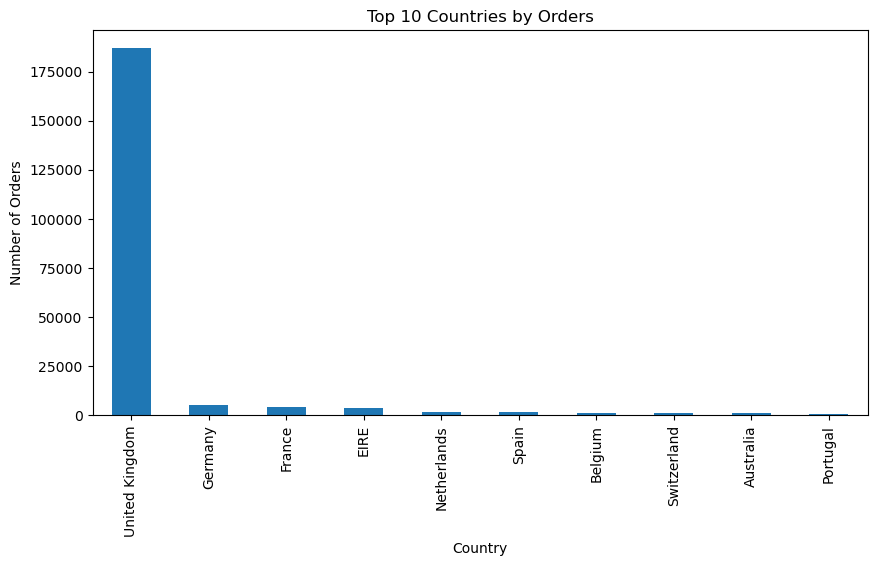

In [11]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Orders')
plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.show()

# Revenue Analysis

In [3]:
print("Total Revenue:", df['Revenue'].sum())
print("Average Revenue:", df['Revenue'].mean())
print("Maximum Revenue:", df['Revenue'].max())
print("Minimum Revenue:", df['Revenue'].min())

Total Revenue: 4886598.402
Average Revenue: 23.190447816017766
Maximum Revenue: 77183.6
Minimum Revenue: 0.0


In [4]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

print(top_products)

Description
REGENCY CAKESTAND 3 TIER              101353.60
MEDIUM CERAMIC TOP STORAGE JAR         79555.59
WHITE HANGING HEART T-LIGHT HOLDER     70045.64
PARTY BUNTING                          54277.70
JUMBO BAG RED RETROSPOT                49077.68
POSTAGE                                47813.01
PICNIC BASKET WICKER 60 PIECES         39619.50
ASSORTED COLOUR BIRD ORNAMENT          34794.58
CHILLI LIGHTS                          26333.81
Manual                                 25356.61
Name: Revenue, dtype: float64


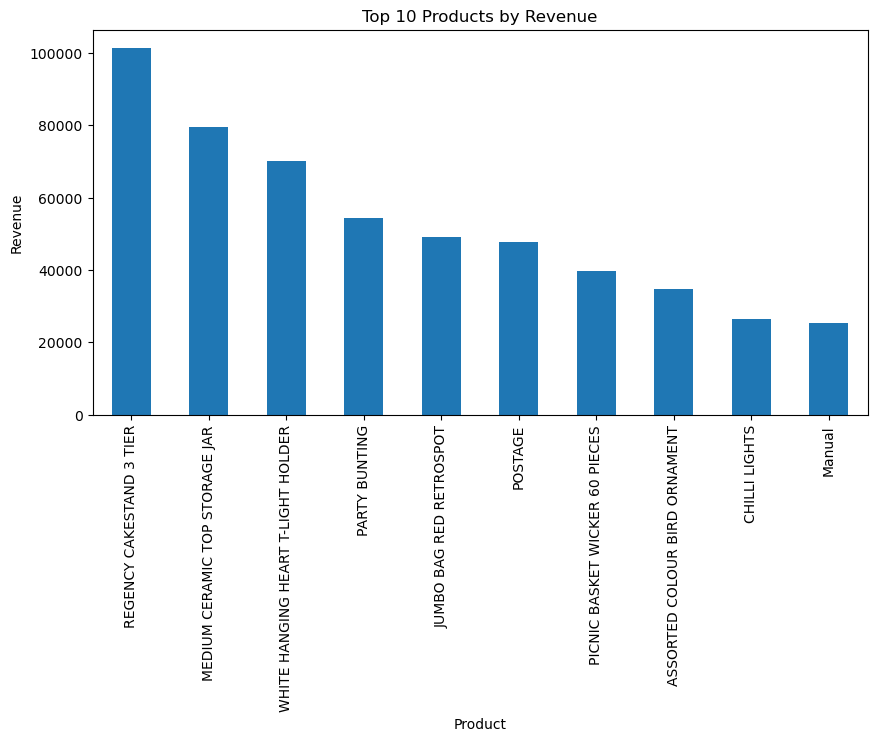

In [5]:
plt.figure(figsize=(10,5))
top_products.plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.show()